In [1]:
import torch
import torch.nn as nn
import numpy as np

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [3]:
data = np.load('50k_dataset.npy')
dataset_size = len(data)
split_index = int(dataset_size*0.75)

In [4]:
# Create training data tensors
X = data[:, :8].astype(np.float32) 
Y = data[:, 11].reshape(-1, 1).astype(np.float32)  # delta_theta

# 10,000 steps in total, we will employ a 75:25 split in training:test data to keep consistent with the source ESN implementation of this experiment.
X_train, Y_train = X[0:split_index], Y[:split_index]
X_test, Y_test = X[split_index:], Y[split_index:]

# insert a new dimension for batches - in this case, we are just putting everything intp 1 batch.
X_train = torch.tensor(X_train).unsqueeze(0)
Y_train = torch.tensor(Y_train).unsqueeze(0)

X_test = torch.tensor(X_test).unsqueeze(0)
Y_test = torch.tensor(Y_test).unsqueeze(0)

In [5]:
print(data_labels.sum())

NameError: name 'data_labels' is not defined

In [6]:
# Variables to test
num_hidden_layers = 128

In [5]:
class OneLayerLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=128):
        # This method describes the basic architechture of the LSTM.
        # We have an LSTM taking input from 8 sensors, and passes that information onto hidden_size amount of hidden layers (default 128) 
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1) # output to left or right

    def forward(self, x, hidden=None):
        output, (h_n, c_n) = self.lstm(x, hidden) # updating the hidden layer for the next recursion
        # output is the hidden layer representation
        # pred is the projection from output to 1 dimension value
        pred = self.fc(output) # most recent hidden layer fully connected to one node -> pred (left or right)
        return pred, output, (h_n, c_n)

In [6]:
class TwoLayerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size):
        # This method describes the basic architechture of the LSTM.
        # We have an LSTM taking input from 8 sensors, and passes that information onto hidden_size amount of hidden layers (default 128) 
        super().__init__()
        self.lstm = nn.LSTM(input_size=8, hidden_size=128, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1) # output to left or right

    def forward(self, x, hidden=None):
        output, (h_n, c_n) = self.lstm(x, hidden) # updating the hidden layer for the next recursion
        # output is the hidden layer representation
        # pred is the projection from output to 1 dimension value
        pred = self.fc(output) # most recent hidden layer fully connected to one node -> pred (left or right)
        return pred, output, (h_n, c_n)

In [6]:
lstm = OneLayerLSTM(8, 128)
# out, (h_n, c_n) = lstm(X_train)

In [7]:
import time
# arbitrary, play around later
optimizer = torch.optim.Adam(lstm.parameters(), lr=1e-3)
criterion = nn.MSELoss()
lstm.train()
# since the ESN example had a warmup phase, a warmup for the LSTM will also be implemented for the sake of consistency.
warmup = 100
# Time and throughput benchmarks are commented out
epoch_times = []
start_total_training_time = time.perf_counter()
# training time!
n_epochs = 200
for epoch in range(n_epochs):
    start_epoch_time = time.perf_counter()
    optimizer.zero_grad()
    pred, all_hidden_states, (h_n, c_n) = lstm(X_train)

    # skip warmup period in loss calculation, like the ESN does
    loss = criterion(pred[:, warmup:, :], Y_train[:, warmup:, :])
    loss.backward()
    optimizer.step()

    end_epoch_time = time.perf_counter()
    epoch_times.append(end_epoch_time - start_epoch_time)
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {loss.item():.5f}")


end_total_training_time = time.perf_counter()
total_time = end_total_training_time - start_total_training_time

epoch_times = np.array(epoch_times)
print(f"\nTraining Throughput Benchmarks:")
print(f"Total training time:      {total_time:.2f}s")
print(f"Mean time per epoch:      {epoch_times.mean():.4f}s")
print(f"Std dev per epoch:        {epoch_times.std():.4f}s")
print(f"Min epoch time:           {epoch_times.min():.4f}s")
print(f"Max epoch time:           {epoch_times.max():.4f}s")
print(f"Throughput:               {n_epochs / total_time:.2f} epochs/sec")
print(f"Timesteps/sec:            {(n_epochs * X_train.shape[1]) / total_time:.0f}")


Epoch 0, loss: 16.75972
Epoch 20, loss: 14.80544
Epoch 40, loss: 12.63692
Epoch 60, loss: 11.50075
Epoch 80, loss: 11.27600
Epoch 100, loss: 11.28738
Epoch 120, loss: 10.98279
Epoch 140, loss: 11.55821
Epoch 160, loss: 10.92238
Epoch 180, loss: 10.82148

Training Throughput Benchmarks:
Total training time:      1305.77s
Mean time per epoch:      6.5288s
Std dev per epoch:        0.0794s
Min epoch time:           6.3634s
Max epoch time:           6.9468s
Throughput:               0.15 epochs/sec
Timesteps/sec:            5744


In [ ]:
# From here, we analyze the internal representation of the LSTM with KNN and SVM.

In [8]:
xy_coords = data[split_index:, 8:10] # x y coordinates of bot at every timestep (in the test data)

def get_yellow_zone_labels(xy):
    yellow_mask = (xy[:, 0] > 100) & (xy[:, 0] < 200) & \
                  (xy[:, 1] > 200) & (xy[:, 1] < 300)
    
    labels = np.zeros(len(xy), dtype=int)
    current_label = 0
    prev_zone = None

    for i in range(len(xy)):
        if xy[i][1] > 350:
            zonet1= 1
        elif xy[i][1] < 150:
            zonet1= 4
        elif xy[i][0] < 150:
            zonet1= 2
        else:
            zonet1= 3
        # only update label on zone 2 or 3 transitions
        if zonet1 != prev_zone:
            if zonet1 == 2:
                current_label = 1
            elif zonet1 == 3:
                current_label = 0      
        prev_zone = zonet1
        
        if yellow_mask[i]:
            labels[i] = current_label
    """
        if xy[i][1] > 300:
            zonet1 = 1
        elif xy[i][1] < 200:
            zonet1 = 4
        elif xy[i][0] < 150:
            zonet1 = 2
        else:
            zonet1 = 3
    """
        

    return labels, yellow_mask

data_labels, yellow_mask = get_yellow_zone_labels(xy_coords)
print(f"Yellow zone points: {yellow_mask.sum()}")
print(f"Label distribution: {np.bincount(data_labels[yellow_mask])}")

Yellow zone points: 1720
Label distribution: [854 866]


In [9]:
# KNN analysis on inference
lstm.eval()
with torch.no_grad():
    pred, all_hidden_states, (h_n, c_n) = lstm(X_test)
all_hidden_states = all_hidden_states.squeeze(0).numpy()

In [12]:
n_neighbors = 6 #test different values

In [23]:
print(data.shape)

(50000, 12)


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

knn_scores = []

for k in range(2, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    
    H_train, H_test, l_train, l_test = train_test_split(all_hidden_states, data_labels, test_size=0.3)
    knn.fit(H_train, l_train)
    knn_pred=knn.predict(H_test)
    knn_scores.append(accuracy_score(l_test, knn_pred))
    print(f"K={k} accuracy: {accuracy_score(l_test, knn_pred):.4f}")


K=2 accuracy: 0.9568
K=3 accuracy: 0.9493
K=4 accuracy: 0.9533
K=5 accuracy: 0.9512
K=6 accuracy: 0.9488
K=7 accuracy: 0.9523
K=8 accuracy: 0.9421
K=9 accuracy: 0.9467
K=10 accuracy: 0.9520
K=11 accuracy: 0.9504
K=12 accuracy: 0.9389
K=13 accuracy: 0.9491
K=14 accuracy: 0.9491
K=15 accuracy: 0.9435
K=16 accuracy: 0.9453
K=17 accuracy: 0.9443
K=18 accuracy: 0.9424
K=19 accuracy: 0.9432


In [23]:
print(lstm.lstm.hidden_size)

256


In [ ]:
# Train and run KNN and SVM classifiers on the raw data

knn_scores_raw_data = []

S_yellow = Data_set[training_len:, :8][yellow_mask]
L_yellow = data_labels[yellow_mask]

for k in range(2, 20):
    knn = KNeighborsClassifier(n_neighbors=k)
    
    H_train, H_test, l_train, l_test = train_test_split(all_hidden_states, data_labels, test_size=0.3)
    knn.fit(H_train, l_train)
    knn_pred=knn.predict(H_test)
    knn_scores.append(accuracy_score(l_test, knn_pred))
    print(f"K={k} accuracy: {accuracy_score(l_test, knn_pred):.4f}")


[0.9568, 0.9493333333333334, 0.9533333333333334, 0.9512, 0.9488, 0.9522666666666667, 0.9421333333333334, 0.9466666666666667, 0.952, 0.9504, 0.9389333333333333, 0.9490666666666666, 0.9490666666666666, 0.9434666666666667, 0.9453333333333334, 0.9442666666666667, 0.9424, 0.9432]


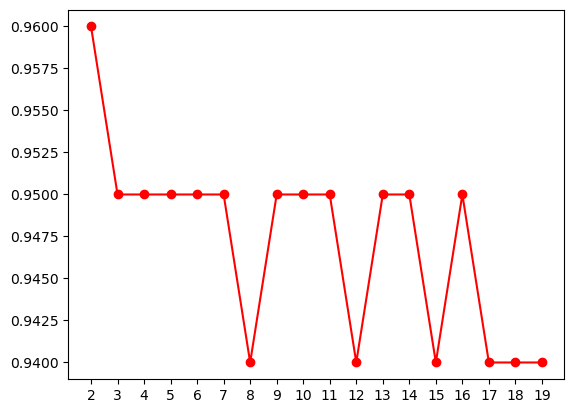

In [24]:
print(knn_scores)
# Elbow method for finding optimal K:
import matplotlib.pyplot as plt
plt.plot(list(range(2,20)), [round(num, 2) for num in knn_scores], 'ro-')
plt.xticks(list(range(2,20)))
#plt.show()
plt.savefig("knn_lstm_50k_128.png")

In [22]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(H_train, l_train)
preds_svm = svm.predict(H_test)
print(f"SVM accuracy: {accuracy_score(l_test, preds_svm):.4f}")

SVM accuracy: 0.9296


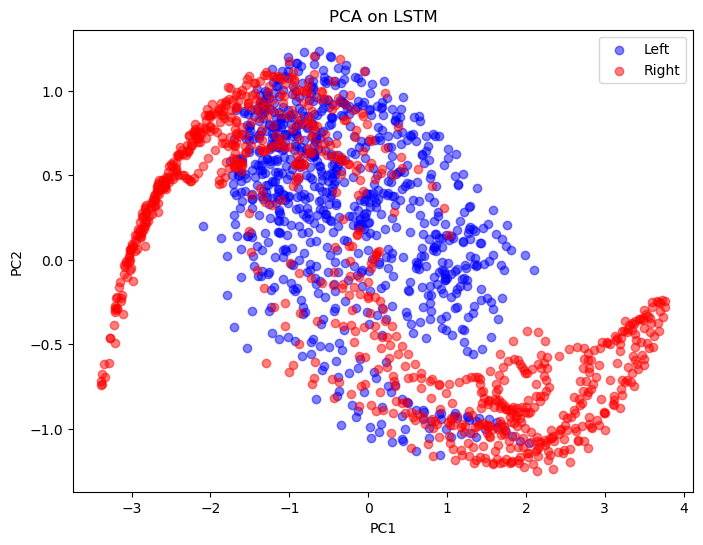

Variance explained: [0.79134136 0.10852746]


In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
H_pca = pca.fit_transform(all_hidden_states)

plt.figure(figsize=(8,6))
plt.scatter(H_pca[yellow_mask & (data_labels==0), 0],
            H_pca[yellow_mask & (data_labels==0), 1],
            alpha=0.5, label='Left', c='blue')
plt.scatter(H_pca[yellow_mask & (data_labels==1), 0],
            H_pca[yellow_mask & (data_labels==1), 1],
            alpha=0.5, label='Right', c='red')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA on LSTM')
plt.legend()
plt.show()

print(f"Variance explained: {pca.explained_variance_ratio_}")

In [26]:
def fishers_discriminant(H, labels):
    H0 = H[labels == 0]
    H1 = H[labels == 1]
    
    mu0, mu1 = H0.mean(axis=0), H1.mean(axis=0)
    
    # within-class scatter
    S_w = np.cov(H0.T) + np.cov(H1.T)
    
    # between-class scatter
    diff = (mu0 - mu1).reshape(-1, 1)
    S_b = diff @ diff.T
    
    # Fisher criterion: higher = more separable
    fisher = np.trace(S_b) / (np.trace(S_w) + 1e-8)
    return fisher

H_yellow = all_hidden_states[yellow_mask]
L_yellow = data_labels[yellow_mask]

print(f"Fisher criterion: {fishers_discriminant(H_yellow, L_yellow):.4f}")

Fisher criterion: 0.0618


In [15]:
training_len = int(len(data)*0.75)
def get_zones(position):
    if position[0,1] >350 : 
        return 1
    elif  position[0,1]<150:
        return 4
    elif position[0,0]<175 :
        return 2
    else : return 3

end_pos = data[training_len, 8:10]
end_orientation = data[training_len, 10]
print(f"End position: {end_pos}")
print(f"End zone: {get_zones(end_pos.reshape(1,2))}")

End position: [214.93746018 262.52781335]
End zone: 3


In [18]:
def nrmse(preds, target): # returns nrmse and r^2 mean values
    #NRMSE
    mse = torch.mean((preds - target) ** 2)
    rmse = torch.sqrt(mse)
    nrmse_mean = rmse / target.mean()

    #R^2
    ss_res = torch.sum((target - preds) ** 2)
    ss_tot = torch.sum((target - target.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return nrmse_mean, r2

3
Steps before failure: 361
Zone at failure: 4, zones completed: 2, full tours: 0


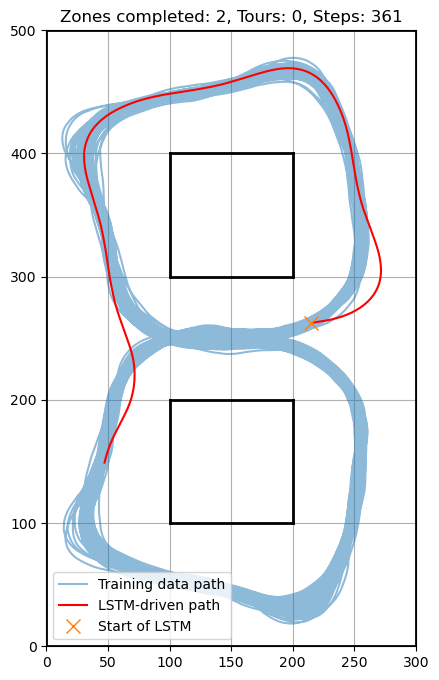

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ── maze geometry ─────────────────────────────────────────────────────────────
walls = np.array([
    [(  0,   0), (  0, 500)],
    [(  0, 500), (300, 500)],
    [(300, 500), (300,   0)],
    [(300,   0), (  0,   0)],
    [(100, 100), (200, 100)],
    [(200, 100), (200, 200)],
    [(200, 200), (100, 200)],
    [(100, 200), (100, 100)],
    [(100, 300), (200, 300)],
    [(200, 300), (200, 400)],
    [(200, 400), (100, 400)],
    [(100, 400), (100, 300)],
])

def line_intersect(p1, p2, P3, P4):
    p1 = np.atleast_2d(p1)
    p2 = np.atleast_2d(p2)
    P3 = np.atleast_2d(P3)
    P4 = np.atleast_2d(P4)
    x1, y1 = p1[:,0], p1[:,1]
    x2, y2 = p2[:,0], p2[:,1]
    X3, Y3 = P3[:,0], P3[:,1]
    X4, Y4 = P4[:,0], P4[:,1]
    D = (Y4-Y3)*(x2-x1) - (X4-X3)*(y2-y1)
    C = (D != 0)
    UA = np.divide((X4-X3)*(y1-Y3) - (Y4-Y3)*(x1-X3), D, where=C)
    UB = np.divide((x2-x1)*(y1-Y3) - (y2-y1)*(x1-X3), D, where=C)
    C = C * (UA > 0) * (UA < 1) * (UB > 0) * (UB < 1)
    X = np.where(C, x1 + UA*(x2-x1), np.inf)
    Y = np.where(C, y1 + UA*(y2-y1), np.inf)
    return np.stack([X, Y], axis=1)

def through_walls(position):
    x, y = position[0,0], position[0,1]
    if (x < 0 or x > 300) or (y < 0 or y > 500):
        return False
    if (x > 100 and x < 200 and y > 100 and y < 200):
        return False
    if (x > 100 and x < 200 and y > 300 and y < 400):
        return False
    return True

def get_zones(position):
    if position[0,1] > 350:
        return 1
    elif position[0,1] < 150:
        return 4
    elif position[0,0] < 150:
        return 2
    else:
        return 3

def lstm_step(sensor_values, hidden):
    x = torch.tensor(sensor_values, dtype=torch.float32).reshape(1, 1, 8)
    with torch.no_grad():
        pred, _, hidden = lstm(x, hidden)
    dv = float(pred[0, 0, 0])
    return dv, hidden

# ── sensor setup ──────────────────────────────────────────────────────────────
robot_size = 10
A_angles = np.linspace(-np.pi/2, +np.pi/2, 8, endpoint=True)
sensors = {
    "angle": A_angles,
    "range": 75 * np.ones((8, 1)),
    "value": np.ones((8, 1))
}
sensors["range"][3:5] *= 1.25


# ── path generation loop ──────────────────────────────────────────────────────
pred = 20_000
lstm_path = np.zeros((pred, 13))
orientation = np.array(data[split_index,10])
position = np.array([data[split_index,8],data[split_index,9]]).reshape((1,2))

# ── zone/pattern setup — set to match actual end zone of training ─────────────
pattern = [3, 1, 2, 3, 4, 2]
zone = get_zones(position)
print(zone)
idx = 0
step_counter = 0
hidden = None # hidden state

for n in range(pred):
    if not through_walls(position):
        break

    zonet1 = get_zones(position)
    if zone == zonet1:
        step_counter += 1
        if step_counter > 300:
            break
    else:
        if zonet1 == pattern[(idx+1) % 6]:
            idx += 1
            zone = zonet1
            step_counter = 0
        else:
            break

    # compute sensor readings
    A = sensors["angle"] + orientation
    T = np.stack([np.cos(A), np.sin(A)], axis=1)
    P1 = position + robot_size * T
    P2 = P1 + sensors["range"] * T
    P3, P4 = walls[:,0], walls[:,1]
    for i, (p1, p2) in enumerate(zip(P1, P2)):
        C = line_intersect(p1, p2, P3, P4)
        index = np.argmin(((C - p1)**2).sum(axis=1))
        p = C[index]
        if p[0] < np.inf:
            sensors["value"][i] = np.sqrt(((p1-p)**2).sum())
            sensors["value"][i] /= sensors["range"][i]
        else:
            sensors["value"][i] = 1

    lstm_path[n, :8] = sensors["value"].reshape((8,))

    # lstm step — hidden state carried forward
    dv, hidden = lstm_step(sensors["value"].reshape((8,)), hidden)

    if abs(dv) > 0.5:
        orientation += 0.01 * dv
    else:
        dv = 0

    lstm_path[n, 9] = dv
    position += 2 * np.array([np.cos(float(orientation)),
                               np.sin(float(orientation))]).reshape((1, 2))
    lstm_path[n, 10] = position[0,0]
    lstm_path[n, 11] = position[0,1]
    lstm_path[n, 12] = orientation

print(f"Steps before failure: {n}")
print(f"Zone at failure: {zonet1}, zones completed: {idx}, full tours: {idx//6}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
for wall in walls:
    (x1, y1), (x2, y2) = wall
    ax.plot([x1, x2], [y1, y2], 'k-', linewidth=2)

ax.plot(data[:split_index, 8], data[:split_index, 9],
        label='Training data path', alpha=0.5)
ax.plot(lstm_path[:n, 10], lstm_path[:n, 11], 'r-', label='LSTM-driven path')
ax.plot(data[split_index, 8], data[split_index, 9],
        'x', label='Start of LSTM', markersize=10)

ax.set_xlim(0, 300)
ax.set_ylim(0, 500)
ax.set_aspect('equal')
ax.set_title(f"Zones completed: {idx}, Tours: {idx//6}, Steps: {n}")
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
nrmse()